In [1]:
import requests
import pandas as pd
import io
import matplotlib.pyplot as plt
import datetime

In [2]:
lts_api_link = "https://swdd9r1vei.execute-api.eu-north-1.amazonaws.com/lts_items"

In [3]:
lts_data = requests.get(lts_api_link)

In [4]:
lts_data

<Response [200]>

In [5]:
type(lts_data.json()[0])

dict

In [6]:
df_ltsd = pd.DataFrame(lts_data.json())
df_ltsd['id']= pd.to_datetime(df_ltsd['id'])
df_ltsd.set_index("id",inplace=True)
df_ltsd.sort_index(inplace = True)
df_ltsd["profit"] = df_ltsd["Total_d_rev"] - df_ltsd["Total_c_cost"]
decisions = df_ltsd[["charge","discharge","soc"]]
decisions["discharge"] = -decisions["discharge"]
system_info = df_ltsd[["Price","SI"]]
profit = df_ltsd[["Total_d_rev","Total_c_cost","profit"]]

C:\Users\u0138303\AppData\Local\Temp\ipykernel_23740\4294666332.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  decisions["discharge"] = -decisions["discharge"]


<Axes: xlabel='id'>

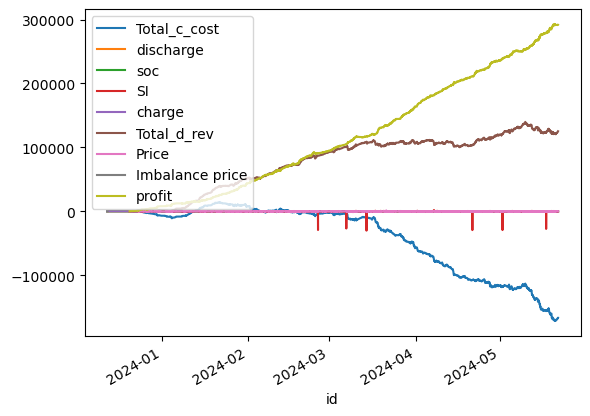

In [6]:
df_ltsd.plot()

In [20]:
df_ltsd

,Total_c_cost,discharge,soc,SI,charge,Total_d_rev,Price,writing_time,Imbalance price,profit
id,,,,,,,,,,
2023-12-12 12:00:00,NaN,1.000000e+00,1.000000e+00,NaN,7.075590e-10,NaN,NaN,"2023/12/12, 14:17:28",1.0,NaN
2023-12-12 15:45:00,NaN,5.028427e-10,3.547220e-10,NaN,-3.727583e-10,NaN,NaN,"2023/12/12, 17:33:10",1.0,NaN
2023-12-20 13:45:00,0.000000e+00,1.000000e+00,1.000000e+00,0.000,8.132172e-11,0.000000,0.00,"2023/12/21, 22:29:53",NaN,0.000000
2023-12-20 15:00:00,-2.595212e-09,5.998648e-11,1.000000e+00,0.000,3.811132e-10,-53.950000,0.00,"2023/12/21, 22:29:53",NaN,-53.950000
2023-12-20 15:15:00,5.361518e-08,2.862829e-11,2.000000e+00,0.000,1.000000e+00,-53.950000,0.00,"2023/12/21, 22:29:53",NaN,-53.950000
...,...,...,...,...,...,...,...,...,...,...
2024-05-21 18:30:00,-1.670123e+05,1.000000e+00,2.023277e-10,-74.180,1.000000e+00,124549.809737,120.83,"2024/05/21, 18:56:10",NaN,291562.121305
2024-05-21 18:45:00,-1.670123e+05,3.652552e-10,1.741894e-10,-90.437,3.805492e-10,124549.809737,75.26,"2024/05/21, 19:11:11",NaN,291562.121305
2024-05-21 19:30:00,-1.665485e+05,1.000000e+00,5.224913e-10,-76.394,1.000000e+00,125013.669736,118.74,"2024/05/21, 19:57:14",NaN,291562.121305


In [17]:
(df_ltsd["discharge"] * df_ltsd["Price"]).sum()

49140.19005132881

In [19]:
(df_ltsd["charge"] * df_ltsd["Price"]).sum()  - (df_ltsd["discharge"] * df_ltsd["Price"]).sum()

-134448.11845582857

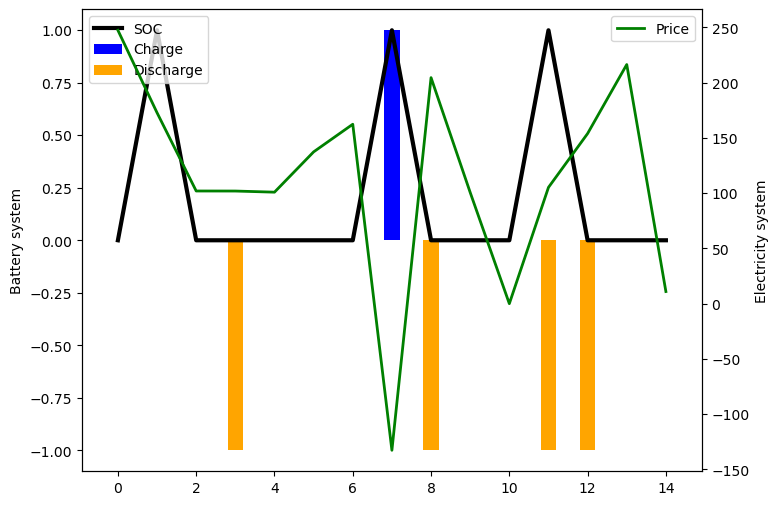

In [10]:
start = datetime.datetime(2024, 1, 1)
end = start + datetime.timedelta(months=2)  # Change to 6 hours

fig, axs = plt.subplots(1, figsize=(8, 6))

ax1 = axs
ax2 = ax1.twinx()

# Collect values
charge = decisions.loc[start:end, ["charge"]].values.flatten()
discharge = decisions.loc[start:end, ["discharge"]].values.flatten()
soc = decisions.loc[start:end, ["soc"]].values.flatten()
price = system_info.loc[start:end, ["Price"]].values.flatten()

# Plot bar charts
ax1.bar(range(len(charge)), charge, label='Charge', color='blue', width=0.4)
ax1.bar(range(len(discharge)), discharge, label='Discharge', color='orange', width=0.4)

# Plot line chart
ax1.plot(range(len(soc)), soc, label='SOC', color='black', linewidth=3)

# Plot line chart for 'price'
ax2.plot(range(len(price)), price, label='Price', color='green', linewidth=2)

ax1.set_ylabel('Battery system')
ax2.set_ylabel('Electricity system')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()


In [29]:
start = datetime.datetime(2024, 1, 3)
end = start + datetime.timedelta(hours=48)
df_ltsd[start:end]

,Total_c_cost,discharge,soc,SI,charge,Total_d_rev,Price,writing_time,Imbalance price,profit
id,,,,,,,,,,
2024-01-03 00:15:00,-8330.130557,1.000000e+00,1.000000e+00,31.788,-8.779522e-09,688.441067,-154.45,"2024/01/03, 00:41:08",NaN,9018.571624
2024-01-03 00:30:00,-8377.610550,9.999999e-01,1.000000e+00,10.787,9.999998e-01,640.961071,-47.48,"2024/01/03, 00:56:08",NaN,9018.571620
2024-01-03 00:45:00,-8377.610550,1.000000e+00,1.451029e-09,28.538,-1.413339e-09,603.941071,-37.02,"2024/01/03, 01:11:08",NaN,8981.551620
2024-01-03 01:15:00,-8377.610549,3.314182e-09,-2.610507e-11,-6.487,3.059339e-09,603.941071,167.66,"2024/01/03, 01:41:09",NaN,8981.551620
2024-01-03 01:30:00,-8377.610549,1.430163e-10,-1.972483e-11,37.096,1.443782e-10,603.941071,-38.16,"2024/01/03, 01:57:11",NaN,8981.551620
...,...,...,...,...,...,...,...,...,...,...
2024-01-04 22:00:00,-9928.600570,1.026764e-09,6.822856e-10,-65.931,-9.115366e-10,1480.421075,162.61,"2024/01/04, 22:26:10",NaN,11409.021644
2024-01-04 22:30:00,-9966.330570,-1.389544e-10,1.000000e+00,46.843,1.000000e+00,1480.421074,-37.73,"2024/01/04, 22:56:09",NaN,11446.751644
2024-01-04 23:15:00,-9966.330570,1.000000e+00,1.000000e+00,-52.819,3.850111e-10,1590.091074,109.67,"2024/01/04, 23:41:10",NaN,11556.421644


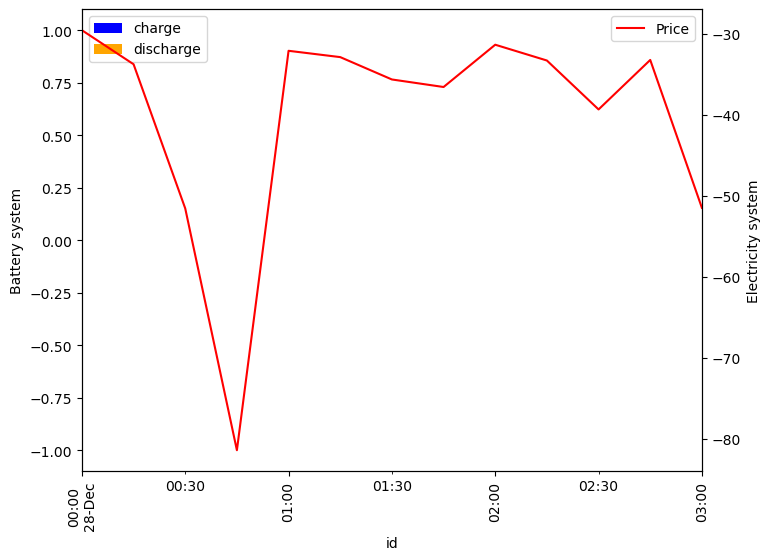

In [210]:
decisions.loc[start:end, ["charge"]].values

array([[5.71115534e-09],
       [9.99999995e-01],
       [1.00000000e+00],
       [9.99999695e-01],
       [2.37157881e-07],
       [9.99999999e-01],
       [9.99999998e-01],
       [1.62524673e-10],
       [8.49146855e-11],
       [1.16537507e-10],
       [7.66229463e-11],
       [1.07140053e-09],
       [1.43543408e-05]])